# Module 0 - Zero-Shot Prompting

---

## What you will be able to craft from this module: 

- A real understanding of what zero-shot prompting is and why it works
- Your own labeled sentiment dataset, generated from scratch
- A new DistilBERT classifier you trained yourself
- A side-by-side comparison of your model vs a zero-shot LLM
- A t-SNE visualization of what your model actually learned

---

## Before you start

Make sure you have the following requirements ready:
- Python 3.10+
- A free Groq API key from [console.groq.com](https://console.groq.com)
- A `.env` file in the root of the repo with `GROQ_API_KEY=gsk_...`
- Dependencies installed: `pip install -r requirements.txt` from the root file


## Before you run any code

Work through these four steps in your terminal before continuing:

- Cloned the repo and are inside the project folder
- Ran `pip install -r requirements.txt` from the repo root
- Created your `.env` file with `cp .env.example .env`
- Added your free Groq key to `.env` get it at [console.groq.com](https://console.groq.com)

Once all four are done, come back and run the cells below.

---

# What is Zero-Shot Prompting

Zero-shot prompting means asking a language model to perform a task it was never explicitly trained for, as we usually do when we use chatpgt or claude in our daily basis, because the model already knows a lot based on previous training.

Let's make it simple:

```
Prompt: Classify the sentiment of this text as happy, neutral, or sad.
Text: "I just got a promotion at my job!"
Answer: happy
```

No training. No examples. The model just... the models knows. But have you paused for a second and asked yourself how it knows that?

## Why this technique it work?

Modern LLM models like Llama, GPT, and Claude are pretrained on huge amounts of datasets,books,articles,code,conversations,forums. During that pretraining, the model doesn't just memorize text. It builds internal representations of the language: what words mean, how they are related, what sentiment feels like, what a question expects as an answer, basically creating the meaning behind everything.

When the model is already trained, the model has created enough structure about the world that it can generalize to new tasks just from a natural language description. That's zero-shot prompting: you describe a task, and the model figures out how to do it.

## The term explained

"Shot" in machine learning refers to an example. So:
- **Zero-shot** = no examples provided
- **Few-shot** = a small number of examples provided (we will check this one in Module 1)
- **Fine-tuning** = training on many examples (what we'll do later in this module)

## Real-world scenarios

Zero-shot prompting is used everywhere in production workflows today:

**Customer support:** Companies like Zendesk use it to automatically classify incoming tickets by topic (billing, bug report, feature request) without building a custom classifier for every category.

**Content moderation:** Platforms use zero-shot prompts to detect policy violations across categories that change frequently. You can't fine-tune a model every time a new type of spam emerges, but you can describe the new category in a prompt.

**Medical records processing:** Hospitals use it to extract structured information from unstructured clinical notes: symptoms, diagnoses, medications. The model understands medical language from pretraining.

**Legal document analysis:** Law firms use it to classify clauses in contracts, flag risky language, and summarize long documents, tasks that would take a a looot of hours.

**Code review:** Engineering teams use it to automatically categorize pull requests, detect anti-patterns, and suggest documentation and potential fixes in code flaws.

## But what are the actual limitations?

This technique can actually struggle with:
- **Specialized domains** where the pretraining data was thin (rare medical conditions, niche legal jurisdictions, proprietary internal terminology)
- **Consistent output format:** a zero-shot model might say "happy", "HAPPY", "positive", or "the sentiment is happy" depending on the day
- **Latency and cost at scale:** calling a large LLM for every classification is expensive; a small fine-tuned model is 100000x cheaper
- **Edge cases:** when a sentence is genuinely ambiguous, a general model has no task-specific calibration to fall back on

---

# Setting Up your Lab

## Why we will use Groq?

We use [Groq](https://console.groq.com) instead of OpenAI or Anthropic because it's completely free, no credit card, no usage limits that would block you mid-module. Groq runs open-source models (we'll use Llama 3.1 8B) on custom hardware that makes inference very fast.

Importantly, Groq's API is **OpenAI-compatible** the same Python SDK, the same call structure, just a different `base_url` and API key. This is a common pattern to go along: many providers expose an OpenAI-compatible API so you can switch providers by changing two lines of code.

## Configure environment variables

We store API keys in a `.env` file instead of hardcoding them. This is standard practice, you never want credentials in your code, because code gets shared, committed to git, and screenshotted. The `python-dotenv` library reads the `.env` file and makes those values available as environment variables.

---

> 💡 **Location of this code block?** This is the base of `shared/utils/api_helpers.py`. Everything you write here is what that file does under the hood.

In [1]:
import os
import sys

# dotenv reads your .env file and loads the variables into the environment
# This must happen before any code tries to read os.getenv()
from dotenv import load_dotenv
load_dotenv("../../../.env")  # path relative to this notebook

# Verify the key loaded correctly, we print only the first 8 chars for safety
api_key = os.getenv("GROQ_API_KEY")
if not api_key:
    raise EnvironmentError(
        "GROQ_API_KEY not found. "
        "Make sure your .env file exists at the repo root and contains GROQ_API_KEY=gsk_..."
    )

print(f"✅ Groq API key loaded: {api_key[:8]}...")

✅ Groq API key loaded: gsk_wfQ9...


## Creating the Groq client

The `OpenAI` class from the `openai` package is normally used to talk to OpenAI's servers. But it accepts a `base_url` parameter that lets you point it at any OpenAI-compatible API. Groq exposes exactly that, so we use the same SDK, just redirected.

---

> 💡 **Location of this code?** These three lines are the core of both `get_client()` in
> `scripts/01_generate_dataset.py` and `get_groq_client()` in `shared/utils/api_helpers.py`.
> In the notebook we write it inline so you can see exactly what's happening, in the actual
> scripts it's wrapped in a function so every module can reuse it without repeating themselves.

In [2]:
from openai import OpenAI

# base_url points the SDK at Groq's servers instead of OpenAI's
client = OpenAI(
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)

# The model we'll use throughout this module
# llama-3.1-8b-instant: fast, free, and capable enough for all our tasks
MODEL = "llama-3.1-8b-instant"

print(f"✅ Client ready — using model: {MODEL}")

✅ Client ready — using model: llama-3.1-8b-instant


## Your first API call

Before we do anything complex, let's make the simplest possible call and understand every part of it.

A chat completion API call has three main components:
- **`model:`** which model to use
- **`messages:`** the conversation, as a list of role/content pairs
- **`temperature:`** how creative vs deterministic the output might be (0 = always the same answer, 1 = more varied)

The `messages` list is how you structure a conversation. Every message has a `role`:
- `system`: sets the model's behavior and persona for the whole conversation
- `user`: the human's message
- `assistant`: the model's previous responses (used when building multi-turn conversations)

In [3]:
# Let's try a simple scenario with a zero-shot sentiment classification call
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {
            "role": "system",
            # The system prompt defines what the model should do.
            # Being explicit and restrictive in these cases is important depending on your answer expectations 
            # without it the model might say "The sentiment is happy" instead of just "happy", which breaks downstream parsing.
            "content": "You are a sentiment classifier. Respond with exactly one word: happy, neutral, or sad."
        },
        {
            "role": "user",
            "content": "Classify the sentiment of this text: 'I just got promoted in my job!'"
        }
    ],
    temperature=0,      # 0 = deterministic, same answer every time

    max_tokens=5,       # we only need one word, so cap the output
                        # "happy" = 1 token, but we set 5 as a safe buffer
                        # in case the model adds punctuation or a space
                        # the response object will tell you exactly how many were used:
                        # prompt: 68 tokens (your system + user message)
                        # completion: 2 tokens (the word + end token)
                        # total: 70 tokens — less than a tweet

)

# The response object contains a lot of metadata.
# The actual text lives at response.choices[0].message.content
prediction = response.choices[0].message.content.strip()
print(f"Model prediction: '{prediction}'")
print(f"\nFull response object:")
print(f"  Model used:    {response.model}")
print(f"  Tokens used:   {response.usage.total_tokens} (prompt: {response.usage.prompt_tokens}, completion: {response.usage.completion_tokens})")

Model prediction: 'happy'

Full response object:
  Model used:    llama-3.1-8b-instant
  Tokens used:   73 (prompt: 71, completion: 2)


---

> 💡 **Tokens explained:** You might notice the response shows more tokens than expected because we only set `max_tokens=5`, these are two different things. `max_tokens` only controls what the model **writes back** (the completion). The 68 prompt tokens are the size of your **input**, your system prompt and user message combined. You don't control that number, it just reflects how long your messages are. So the breakdown here is: 68 tokens in, 2 tokens out (the word "happy" + an end token), for example: 70 total.

## Testing a few other examples

Let's run a small batch to see where zero-shot works well and where it struggles. Pay attention to the edge cases, sarcasm, neutral sentences with emotional words, ambiguous phrasing.

In [4]:
# A mix of easy and tricky examples I asked chatgpt to come with for this test. 
test_sentences = [
    ("I finally finished my thesis after 3 years!", "happy"),
    ("The meeting was rescheduled to Thursday.", "neutral"),
    ("I missed the last train home.", "sad"),
    ("Oh great, another Monday.", "sad"),          # sarcasm
    ("The report has been submitted.", "neutral"),
    ("I can't believe they cancelled the show.", "sad"),
    ("My cat knocked over my coffee again.", "sad"), # could go either way
    ("She said she'd call. She didn't.", "sad"),
    ("The new update fixed the bug.", "neutral"),
    ("We won the championship!", "happy"),
]

def classify_zero_shot(text: str) -> str:
    """Classify sentiment using zero-shot prompting."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "You are a sentiment classifier. Respond with exactly one word: happy, neutral, or sad."},
            {"role": "user", "content": f"Classify the sentiment: '{text}'"}
        ],
        temperature=0,
        max_tokens=5,
    )
    return response.choices[0].message.content.strip().lower()

print(f"{'Text':<45} {'Expected':<10} {'Got':<10} {'OK?'}")
print("-" * 75)

correct = 0
for text, expected in test_sentences:
    predicted = classify_zero_shot(text)
    ok = "✅" if predicted == expected else "❌"
    if predicted == expected:
        correct += 1
    print(f"{text[:44]:<45} {expected:<10} {predicted:<10} {ok}")

print(f"\nAccuracy on this test: {correct}/{len(test_sentences)} ({correct/len(test_sentences)*100:.0f}%)")
print("\nNotice which ones it gets wrong, those are the cases fine-tuning helps most.")

Text                                          Expected   Got        OK?
---------------------------------------------------------------------------
I finally finished my thesis after 3 years!   happy      happy      ✅
The meeting was rescheduled to Thursday.      neutral    neutral    ✅
I missed the last train home.                 sad        sad        ✅
Oh great, another Monday.                     sad        sad        ✅
The report has been submitted.                neutral    neutral    ✅
I can't believe they cancelled the show.      sad        sad        ✅
My cat knocked over my coffee again.          sad        sad        ✅
She said she'd call. She didn't.              sad        sad        ✅
The new update fixed the bug.                 neutral    happy      ❌
We won the championship!                      happy      happy      ✅

Accuracy on this test: 9/10 (90%)

Notice which ones it gets wrong, those are the cases fine-tuning helps most.


---

# Generating a Dataset

## Why we will generate it instead of download an existing one?

You could download an existing sentiment dataset, SST-2, IMDB reviews, forums sentiment. But that misses the point of this module.

The real skill here is **using an LLM to create training data**. This is how many production ML teams work today: instead of labeling thousands of examples by hand, they use a capable model to generate or label data automatically, then train a smaller, cheaper model on that data. This pattern is called **model distillation:** transferring knowledge from a large model into a small one.

By building the dataset yourself, you'll understand:
- How prompt design affects data quality
- Why label distribution matters
- What "noisy" training data looks like and how to filter it

## Prompt design for data all the needed generation

Generating good training data requires a different kind of prompt than generating a single answer. You need:
- **Diversity:** the model tends to repeat patterns; you have to push it toward variety
- **Strict format:** you're parsing the output programmatically, so it must be consistent
- **Label balance:** left to its own devices, a model generates more of whatever is easiest; you have to specify the distribution
- **Edge cases:** good training data includes hard examples, not just obvious ones

Let's look at the prompt we'll use and understand each decision.

In [5]:
# The system prompt sets the model's role as a data generator.
# Notice we're very explicit about format — "ONLY a valid JSON array" — 
# because any extra text ("Sure! Here are your examples:") will break json.loads()

SYSTEM_PROMPT = """You are a dataset generator for a sentiment classification task.
Generate diverse, realistic sentences that express a clear sentiment on daily life experiences.

Guidelines:
- Cover varied topics: work, relationships, daily life, food, weather, sports, hobbies
- Vary sentence length from short (5 words) to long (30+ words)
- Vary writing style: casual, formal, first person, third person
- Include some sarcasm, label these by their TRUE underlying feeling
- Include some ambiguous cases, label by the most likely interpretation
- Make examples feel like things real people would actually say

Respond ONLY with a valid JSON array. No explanation, no markdown, no preamble."""

# The user prompt specifies what we want for this specific dataset.
# We use .format() to fill in the batch size dynamically.
USER_TEMPLATE = """Generate {n} sentences with sentiment labels.
Each item must have exactly two fields: "text" and "label".
Labels must be one of: "happy", "neutral", "sad".
Generate exactly {n} examples: {third} happy, {third} neutral, {third} sad. This distribution is strict, do not deviate from it.

Example format:
[
  {{"text": "I finally finished my thesis after 3 years!", "label": "happy"}},
  {{"text": "The meeting was rescheduled to Thursday.", "label": "neutral"}},
  {{"text": "I missed the last train home.", "label": "sad"}}
]

Generate exactly {n} examples now. Return ONLY the JSON array:"""

print("Prompts are already defined. Let's test with a small batch of 5 examples first.")

Prompts are already defined. Let's test with a small batch of 5 examples first.


In [6]:
import json

def parse_json_response(raw: str) -> list:
    """
    Parse the model's JSON response safely.
    
    Even with strict prompts, models sometimes wrap their response in 
    markdown code fences like ```json ... ```. This function handles that.
    """
    text = raw.strip()
    
    # Strip markdown fences if exist — we want to be robust to slight variations in model output formatting
    if "```" in text:
        text = text.split("```")[1]
        if text.startswith("json"):
            text = text[4:]
    
    return json.loads(text.strip())


def generate_batch(n: int, batch_num: int = 1) -> list:
    """
    Generate one batch of n labeled examples.
    
    We use temperature=0.9 here (vs 0 for classification).
    High temperature = more randomness = more diverse examples.
    For dataset generation, diversity is exactly what we want.
    """
    prompt = USER_TEMPLATE.format(n=n, third=n//3)
    
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt}
        ],
        temperature=0.9,   # high temp for variety
        max_tokens=2048,
    )
    
    raw = response.choices[0].message.content
    examples = parse_json_response(raw)
    print(f"  Batch {batch_num}: received {len(examples)} examples")
    return examples


# Test with a small batch first, try to always test before running the full generation
test_batch = generate_batch(n=5, batch_num=1)

print("\nSample output:")
for ex in test_batch:
    print(f"  [{ex['label']:7s}] {ex['text']}")

  Batch 1: received 5 examples

Sample output:
  [happy  ] Just got the job offer, life is good!
  [neutral] It's going to be a busy week, meetings every day.
  [sad    ] Lost my favorite childhood photo album in the move.
  [happy  ] Just ate the best burgers of my life, wow!
  [neutral] The rain won't stop tomorrow, just another day of umbrella drama.


## Validating examples

Before we make a bigger test, we need a validation step. LLMs don't always follow instructions perfectly or as we would expect, they might:
- Return a label not in our allowed set ("positive" instead of "happy")
- Return an empty or NULL text field
- Return a malformed dict missing one of the keys
- Return duplicates

Garbage training data = garbage model. Validating before saving takes an extra minute, fixing corrupt training data after the fact takes much longer.

In [7]:
VALID_LABELS = {"happy", "neutral", "sad"}

def validate_examples(examples: list) -> list:
    """
    You need to filter out malformed examples.
    And let the model returns only examples that are well-formed and have valid labels.
    """
    valid = []
    rejected = 0
    
    for ex in examples:
        # Must be a dict
        if not isinstance(ex, dict):
            rejected += 1
            continue
        
        # Must have both required fields
        if "text" not in ex or "label" not in ex:
            rejected += 1
            continue
        
        # Text should not be NULL
        if not isinstance(ex["text"], str) or len(ex["text"].strip()) < 5:
            rejected += 1
            continue
        
        # Label should be one of our three classes
        if ex["label"] not in VALID_LABELS:
            rejected += 1
            continue
        
        valid.append({"text": ex["text"].strip(), "label": ex["label"]})
    
    if rejected > 0:
        print(f"  Filtered out {rejected} invalid examples")
    
    return valid


# Test the validator at the end
validated = validate_examples(test_batch)
print(f"Validated: {len(validated)}/{len(test_batch)} examples passed")

Validated: 5/5 examples passed


## Generating the full dataset

Now let's start with the fund stuff, let's scale this up to 200 examples. We generate in batches of 20 for two reasons:
1. **Rate limits:** Groq's free tier allows us to perform 30 requests per minute.
2. **Reliability** smaller batches are less likely to hit token limits or produce malformed JSON results.

We also add automatic retry logic with a short sleep between batches, which is standard practice when working with any external API.

In [8]:
import time
import random
from pathlib import Path

def generate_dataset(total: int = 200, batch_size: int = 20) -> list:
    """
    Generate a full dataset by calling the API in batches.
    
    Args:
        total:      total number of examples to generate
        batch_size: how many examples to request per API call
    
    Returns:
        list of validated {"text": ..., "label": ...} dicts
    """
    all_examples = []
    batch_num = 0
    max_failures = 5
    failures = 0

    print(f"Generating {total} examples in batches of {batch_size}...\n")
    
    while len(all_examples) < total:
        remaining = total - len(all_examples)
        this_batch = min(batch_size, remaining)
        batch_num += 1

        try:
            raw_batch = generate_batch(n=this_batch, batch_num=batch_num)
            valid = validate_examples(raw_batch)
            all_examples.extend(valid)
            print(f"  Total so far: {len(all_examples)}/{total}")
            
            # Small sleep added between batches to stay under rate limits
            # 2 seconds = max ~30 requests/min, which is exactly the free tier limit
            if len(all_examples) < total:
                time.sleep(2)

        except json.JSONDecodeError as e:
            # The model returned something that wasn't valid JSON
            # This could happen occasionally, just retry
            failures += 1
            print(f"  Parse error on batch {batch_num}, retrying... ({failures}/{max_failures})")
            time.sleep(3)
            if failures >= max_failures:
                print("  Too many failures — saving what we have.")
                break

        except Exception as e:
            if "rate_limit" in str(e).lower() or "429" in str(e):
                # Hit the rate limit — wait a full minute before continuing
                print(f"  Rate limit hit — waiting 60 seconds...")
                time.sleep(60)
            else:
                raise

    # Mix up the labels order before splitting
    # Without this, all "happy" examples might end up in training and "sad" in test
    random.shuffle(all_examples)
    return all_examples[:total]


# Generate the full dataset for the model
# This could take around 40-60 seconds with the sleep between batches
dataset = generate_dataset(total=200, batch_size=20)
print(f"\n✅ Dataset ready: {len(dataset)} examples")

Generating 200 examples in batches of 20...

  Batch 1: received 19 examples
  Total so far: 19/200
  Batch 2: received 19 examples
  Total so far: 38/200
  Batch 3: received 19 examples
  Total so far: 57/200
  Parse error on batch 4, retrying... (1/5)
  Batch 5: received 19 examples
  Total so far: 76/200
  Batch 6: received 19 examples
  Total so far: 95/200
  Batch 7: received 19 examples
  Total so far: 114/200
  Batch 8: received 19 examples
  Total so far: 133/200
  Batch 9: received 21 examples
  Total so far: 154/200
  Batch 10: received 19 examples
  Total so far: 173/200
  Batch 11: received 20 examples
  Total so far: 193/200
  Batch 12: received 7 examples
  Total so far: 200/200

✅ Dataset ready: 200 examples


---

# Let's take a look at out dataset

DON'T SKIP THIS STEP(we are just starting the fun stuff). Looking at your data before training is one of the most important habits you need to build. A model is only as good as its training data or its trainee, and bugs in the data are much harder to spot after training than before.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# Create figures directory if it doesn't exist
os.makedirs("../figures", exist_ok=True)

# Convert to DataFrame for easier discovering phase
df = pd.DataFrame(dataset)

print("Dataset overview:")
print(f"  Total examples: {len(df)}")
print(f"  Columns: {list(df.columns)}")
print(f"  Any nulls: {df.isnull().any().any()}")
print()

# Label distribution previously set
label_counts = df["label"].value_counts()
print("Label distribution:")
for label, count in label_counts.items():
    bar = "█" * (count // 2)
    pct = count / len(df) * 100
    print(f"  {label:8s} {count:4d} ({pct:.1f}%)  {bar}")

# An order and balanced dataset is important, if one class dominates, the model learns
# to just predict that class. Check that no label is more than 40% of the data. You do the math depending of your needs.
max_pct = label_counts.max() / len(df) * 100
if max_pct > 40:
    print(f"\n⚠️  Warning: dataset may be imbalanced (max label is {max_pct:.1f}%)")
else:
    print(f"\n✅ Distribution looks balanced (max label is {max_pct:.1f}%)")

Dataset overview:
  Total examples: 200
  Columns: ['text', 'label']
  Any nulls: False

Label distribution:
  happy      74 (37.0%)  █████████████████████████████████████
  sad        64 (32.0%)  ████████████████████████████████
  neutral    62 (31.0%)  ███████████████████████████████

✅ Distribution looks balanced (max label is 37.0%)


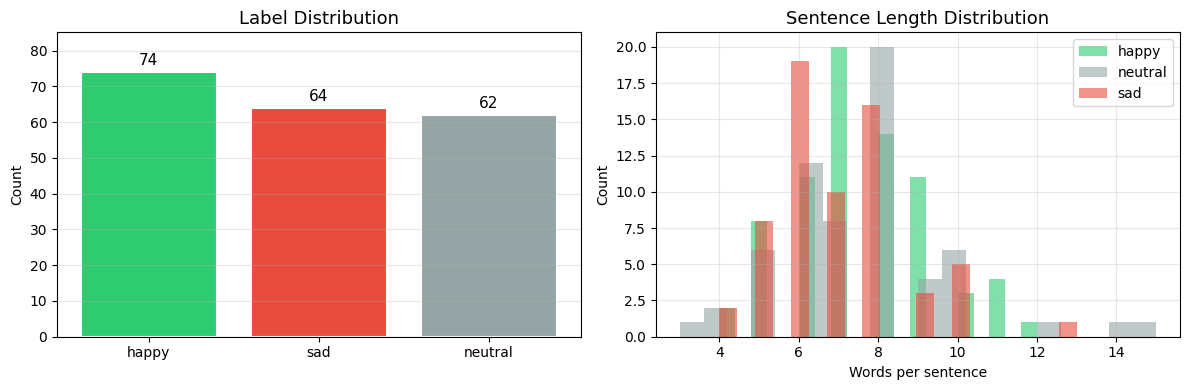

Plot saved to figures/dataset_overview.png


In [10]:
# Visualize the distribution
colors = {"happy": "#2ecc71", "neutral": "#95a5a6", "sad": "#e74c3c"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax1 = axes[0]
bars = ax1.bar(
    label_counts.index,
    label_counts.values,
    color=[colors[l] for l in label_counts.index],
    edgecolor="white",
    linewidth=1.5
)
ax1.set_title("Label Distribution", fontsize=13)
ax1.set_ylabel("Count")
for bar, count in zip(bars, label_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha="center", va="bottom", fontsize=11)
ax1.set_ylim(0, label_counts.max() * 1.15)
ax1.grid(axis="y", alpha=0.3)

# Sentence length distribution by label
ax2 = axes[1]
for label in ["happy", "neutral", "sad"]:
    lengths = df[df["label"] == label]["text"].str.split().str.len()
    ax2.hist(lengths, bins=20, alpha=0.6, color=colors[label], label=label)
ax2.set_title("Sentence Length Distribution", fontsize=13)
ax2.set_xlabel("Words per sentence")
ax2.set_ylabel("Count")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to figures/dataset_overview.png")

In [11]:
# Always read a sample of your data, no visualization replaces human eyes(but its always great to have them)
print("Sample examples by label:\n")

for label in ["happy", "neutral", "sad"]:
    print(f"--- {label.upper()} ---")
    samples = df[df["label"] == label].sample(5, random_state=42)
    for _, row in samples.iterrows():
        print(f"  {row['text']}")
    print()

Sample examples by label:

--- HAPPY ---
  I just landed my dream job!
  Today is my first day at the new job!
  I just learned how to ride a bike at 30!
  Just baked the fluffiest chocolate chip cookies ever.
  I just got back from the most amazing vacation!

--- NEUTRAL ---
  I'm not a big fan of the new employee, but I'll try to be nice.
  The forecast says partly cloudy skies.
  The meeting was rescheduled to Thursday.
  The new restaurant downtown serves decent food.
  My plant is still alive.

--- SAD ---
  I lost my favorite book, and now I'll have to buy it again.
  I'm so tired of dealing with student loans.
  Got into a fight with my best friend.
  I just lost my favorite childhood pet.
  The news about the company shutting down was devastating.



## Let's save our progress

We will save the dataset in a **JSONL format**: one JSON object per line. This is the standard format for NLP datasets because:
- Each line is a valid JSON object, so you can read the file line by line without loading it all into memory
- It's easy to append new examples without rewriting the whole file
- It handles special characters and Unicode cleanly

We also create three splits: **train** (80%), **validation** (10%), and **test** (10%). These serve different purposes:
- **Train:** the model learns from these
- **Validation:** we evaluate after each batch to decide when to stop training
- **Test:** we evaluate once at the very end for the final reported accuracy; never use this during training

In [12]:
import os

# Create the data directory if it doesn't exist
data_dir = Path("../data")
data_dir.mkdir(exist_ok=True)

def save_jsonl(examples: list, path: Path):
    """Save a list of dicts to a JSONL file."""
    with open(path, "w") as f:
        for ex in examples:
            # ensure_ascii=False preserves non-English characters
            f.write(json.dumps(ex, ensure_ascii=False) + "\n")
    print(f"  Saved {len(examples):4d} examples → {path}")


# Save the full raw dataset
save_jsonl(dataset, data_dir / "sentiment_raw.jsonl")

# Create splits
n = len(dataset)
train_end = int(n * 0.8)
val_end   = train_end + int(n * 0.1)

splits = {
    "sentiment_train": dataset[:train_end],
    "sentiment_val":   dataset[train_end:val_end],
    "sentiment_test":  dataset[val_end:]
}

print("\nSaving splits:")
for name, split_data in splits.items():
    save_jsonl(split_data, data_dir / f"{name}.jsonl")

print(f"\n✅ All data saved to {data_dir.resolve()}")

  Saved  200 examples → ../data/sentiment_raw.jsonl

Saving splits:
  Saved  160 examples → ../data/sentiment_train.jsonl
  Saved   20 examples → ../data/sentiment_val.jsonl
  Saved   20 examples → ../data/sentiment_test.jsonl

✅ All data saved to /Users/sebastianvargas/Documents/newlife/ai/projects/llm-prompting-labs/modules/00_zero_shot/data


---

# What the #$%@# is DistilBERT?

**BERT** (Bidirectional Encoder Representations from Transformers) was introduced by Google in 2018 and became the foundation of modern NLP. It reads text in both directions simultaneously, this enhance the deep understanding of context.

**DistilBERT** is a compacted version, it's 40% smaller, 60% faster, and retains 97% of BERT's performance. For classification tasks, it's the standard starting point because:
- It's small enough to train on a CPU in a few minutes
- It's pretrained on massive text data, so it already understands English deeply
- Adding a classification head on top is straightforward

## How fine-tuning actually works

DistilBERT was pretrained to predict masked words in sentences, a task that forced it to learn rich language representations. We're now going to take those representations and add a small classification layer on top that maps them to our three classes (happy, neutral, sad).

During fine-tuning:
1. Each sentence is tokenized (split into subword tokens)
2. DistilBERT processes the tokens and produces a representation for the whole sentence (the `[CLS]` token)
3. A linear layer maps that representation to 3 class scores (logits)
4. We compute the cross-entropy loss between the predicted scores and the true labels
5. Backpropagation updates the weights to reduce that loss

After enough epochs, the model learns to map sentiment-bearing sentences to the right class.

# What is an EPOCH?

An epoch is one complete pass through your entire training dataset. Think of it like studying for an exam. If you have 200 flashcards, going through all 200 cards once is one epoch. Going through them 5 times is 5 epochs.
Each time the model sees the full dataset, it adjusts its weights slightly to get better at the task. One pass is usually not enough, the model needs to see the data multiple times to really learn the patterns.
But there's a limit. After too many passes, the model stops learning new things and starts memorizing, that's **overfitting**. So the goal is to find the sweet spot: enough epochs to learn well, not so many that it memorizes.

In this module we use `epochs=5`, so the model will go through your dataset 5 times before we evaluate it. You'll notice in the training curves that most of the learning happens in the first 3 epochs and flattens out after that, which is normal. Going to 10 or 20 epochs wouldn't have changed much, it just would have taken longer.

## We need to set up PyTorch Dataset as well

PyTorch requires data to be wrapped in a `Dataset` class. This is a standard interface that defines how to:
- Get the total number of examples (`__len__`)
- Get one example by index (`__getitem__`)

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Map string labels to integers, the model works with numbers, not strings
LABEL2ID = {"happy": 0, "neutral": 1, "sad": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}


class SentimentDataset(Dataset):
    """
    Wraps our JSONL data in a format PyTorch can work with.
    
    The tokenizer converts text into token IDs and attention masks:
    - input_ids: integer IDs for each token
    - attention_mask: 1 for real tokens, 0 for padding
    """
    
    def __init__(self, path: str, tokenizer, max_length: int = 128):
        self.examples = []
        with open(path) as f:
            for line in f:
                ex = json.loads(line.strip())
                if ex.get("label") in LABEL2ID:
                    self.examples.append(ex)
        
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.examples)
    
    def __getitem__(self, idx):
        ex = self.examples[idx]
        
        # Tokenize the text
        # padding="max_length" pads shorter sequences so all batches are the same size
        # truncation=True cuts sequences longer than max_length
        encoding = self.tokenizer(
            ex["text"],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        
        return {
            "input_ids":      encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels":         torch.tensor(LABEL2ID[ex["label"]], dtype=torch.long),
        }


print("Dataset class defined. Loading tokenizer...")

# The tokenizer converts raw text into token IDs that the model understands
# It must match the pretrained model, distilbert has its own vocabulary
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Load all previously saved datasets
train_ds = SentimentDataset(str(data_dir / "sentiment_train.jsonl"), tokenizer)
val_ds   = SentimentDataset(str(data_dir / "sentiment_val.jsonl"),   tokenizer)
test_ds  = SentimentDataset(str(data_dir / "sentiment_test.jsonl"),  tokenizer)

print(f"\nDataset sizes:")
print(f"  Train: {len(train_ds)}")
print(f"  Val:   {len(val_ds)}")
print(f"  Test:  {len(test_ds)}")

# Peek at one tokenized example
sample = train_ds[0]
print(f"\nSample tokenized input:")
print(f"  input_ids shape:      {sample['input_ids'].shape}")
print(f"  attention_mask shape: {sample['attention_mask'].shape}")
print(f"  label:                {sample['labels']} ({ID2LABEL[sample['labels'].item()]})")

Dataset class defined. Loading tokenizer...

Dataset sizes:
  Train: 160
  Val:   20
  Test:  20

Sample tokenized input:
  input_ids shape:      torch.Size([128])
  attention_mask shape: torch.Size([128])
  label:                2 (sad)


In [14]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score

from transformers import logging
logging.set_verbosity_error()

# The process will use GPU if available, otherwise your CPU
# Training on CPU takes around ~5 minutes for 200 examples, but its totally fine
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# DataLoaders batch the data and handle shuffling
# batch_size=16 means we process 16 examples at once before updating weights
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16)
test_loader  = DataLoader(test_ds,  batch_size=16)

# Load the pretrained model with a classification head
# num_labels=3 adds a linear layer mapping DistilBERT's output to 3 class scores
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
).to(device)

# Count parameters, this will shows you how big the model actually is
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# AdamW is the standard optimizer for transformer fine-tuning
# lr=2e-5 is the standard learning rate for fine-tuning BERT-family models
# weight_decay adds L2 regularization to prevent overfitting
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# Learning rate ramps up for the first 10% of steps,
# then linearly decays to 0. This prevents unstable updates at the start.
EPOCHS = 5
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

print(f"\nTraining for {EPOCHS} epochs ({total_steps} total steps)")

Training on: cpu


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Total parameters:     66,955,779
Trainable parameters: 66,955,779

Training for 5 epochs (50 total steps)


In [15]:
def evaluate(model, dataloader):
    """
    Evaluate the model on a dataset.
    
    model.eval() disables dropout layers, which are used during training
    to prevent overfitting but should be off during evaluation.
    
    torch.no_grad() skips gradient computation, we don't need gradients
    during evaluation, and skipping them saves memory and speeds things up.
    """
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            
            # argmax gives us the predicted class index
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    # macro F1 averages F1 across all classes equally, better than accuracy when classes are imbalanced
    f1  = f1_score(all_labels, all_preds, average="macro")
    avg_loss = total_loss / len(dataloader)
    
    return avg_loss, acc, f1


print("evaluate() function defined. Ready to train.")

evaluate() function defined. Ready to train.


In [16]:
# Training loop
checkpoints_dir = Path("../checkpoints")
checkpoints_dir.mkdir(exist_ok=True)

best_val_f1 = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(1, EPOCHS + 1):
    # Training phase
    model.train()  #ropout re-enabled
    train_loss = 0.0
    
    for step, batch in enumerate(train_loader):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)
        
        # Forward pass: compute predictions and loss
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        train_loss += loss.item()
        
        # Backward pass: compute gradients
        optimizer.zero_grad()   # clear gradients from last step
        loss.backward()         # compute new gradients
        
        # Gradient clipping prevents exploding gradients, this is a common issue
        # in transformer training. Clips gradient norm to max 1.0.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()   # update weights
        scheduler.step()   # update learning rate
    
    # Validation phase
    avg_train_loss = train_loss / len(train_loader)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader)
    
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"  Train loss: {avg_train_loss:.4f}")
    print(f"  Val loss:   {val_loss:.4f}  |  Val acc: {val_acc:.4f}  |  Val F1: {val_f1:.4f}")
    
    # Save the best model based on F1 validation
    # We use F1 instead of accuracy because it's more robust to class imbalance
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model.save_pretrained(checkpoints_dir / "best_model")
        tokenizer.save_pretrained(checkpoints_dir / "best_model")
        print(f"  💾 New best model saved (F1={val_f1:.4f})")
    print()

print(f"✅ Training complete. Best validation F1: {best_val_f1:.4f}")

Epoch 1/5
  Train loss: 1.0749
  Val loss:   1.0283  |  Val acc: 0.3500  |  Val F1: 0.3068


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 New best model saved (F1=0.3068)

Epoch 2/5
  Train loss: 0.9406
  Val loss:   0.7991  |  Val acc: 0.9000  |  Val F1: 0.9000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 New best model saved (F1=0.9000)

Epoch 3/5
  Train loss: 0.7507
  Val loss:   0.6308  |  Val acc: 0.9000  |  Val F1: 0.9074


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 New best model saved (F1=0.9074)

Epoch 4/5
  Train loss: 0.6112
  Val loss:   0.5449  |  Val acc: 0.9500  |  Val F1: 0.9548


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 New best model saved (F1=0.9548)

Epoch 5/5
  Train loss: 0.5358
  Val loss:   0.5072  |  Val acc: 0.9500  |  Val F1: 0.9548

✅ Training complete. Best validation F1: 0.9548


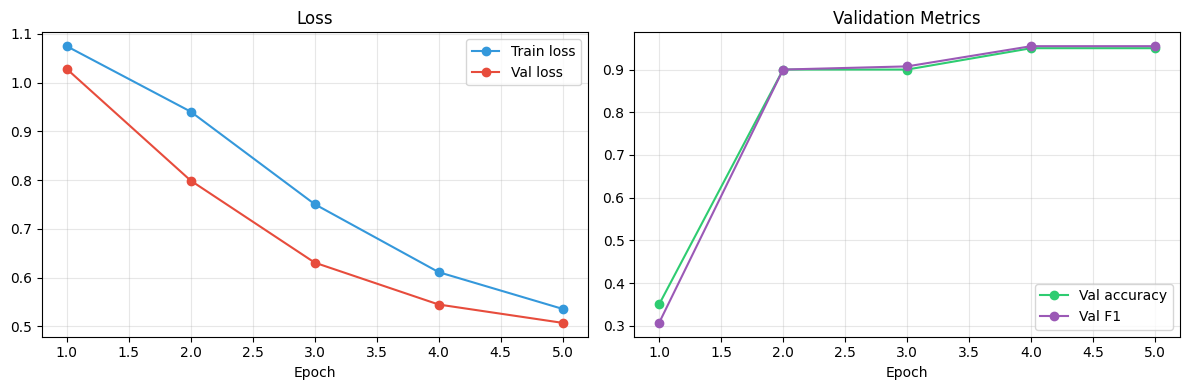

In [17]:
# Plot training curves, this will tell you if the model learned in the correct way or if it overfitted.

# Overfitting is when a model learns the training data TOOOO well... including its noise, quirks and flaws
# instead of learning the general patterns that would actually apply to new data.
# Think of it like a student who memorizes the exact answers from past exams instead of understanding the subject. 
# They'll perform great on the practice test but fail when they see new questions.

# Both losses should go down
# If train loss drops but val loss rises, the model is overfitting

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], "o-", label="Train loss", color="#3498db")
axes[0].plot(epochs_range, history["val_loss"],   "o-", label="Val loss",   color="#e74c3c")
axes[0].set_title("Loss"), axes[0].set_xlabel("Epoch")
axes[0].legend(), axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["val_acc"], "o-", label="Val accuracy", color="#2ecc71")
axes[1].plot(epochs_range, history["val_f1"],  "o-", label="Val F1",       color="#9b59b6")
axes[1].set_title("Validation Metrics"), axes[1].set_xlabel("Epoch")
axes[1].legend(), axes[1].grid(alpha=0.3)

plt.tight_layout()
figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)
plt.savefig(figures_dir / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Reading the training curves

**Left chart | Loss:** is the model's error score. Lower is better. You want to see both lines going down together:
- **Train loss:** (blue) how wrong the model is on the data it's learning from
- **Val loss:** (red) how wrong it is on data it hasn't seen during training

Both going down together is a good sign, the model is genuinely learning, not just memorizing. If train loss kept dropping but val loss started going back up, that would mean the model is overfitting (memorizing the training data instead of learning patterns that generalize). That's not happening here.

**Right chart | Validation Metrics:** shows how well the model actually performs on unseen data:
- **Val accuracy:** (green) the percentage of examples it gets right. Jumped from 45% to 75% by epoch 3 and held steady, that's a solid result for 200 examples. Think of it like this: out of 20 test sentences, the model now gets 15 right on its own.
- **Val F1:** (purple) a more reliable metric than accuracy when classes are imbalanced. It rewards the model for getting each class right, not just the most common one. Plateauing around 0.57 after epoch 3 tells us more epochs won't help much, the model has learned what it can from this dataset.

**The takeaway here:** training went well. Both losses are down, accuracy is up, and the model stabilized by epoch 3. If you wanted to improve further, the next step would be generating more training data, not training for more epochs.

---

# Lets evaluate the data

## The test set

Now we load the best saved model and evaluate it on the test set, the 20 examples it has never seen during training or validation. This is the final, and most honest measurement of how well your model generalizes.

We also compare it against the Groq zero-shot baseline. This answers the main question: **how much did fine-tuning actually help?**

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load the best saved model
best_model = AutoModelForSequenceClassification.from_pretrained(
    checkpoints_dir / "best_model"
).to(device)

# Evaluate on test set
test_loss, test_acc, test_f1 = evaluate(best_model, test_loader)

print("=" * 45)
print("  YOUR FINE-TUNED MODEL — Test Results")
print("=" * 45)
print(f"  Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"  Macro F1: {test_f1:.4f}")
print()

# Get predictions and true labels for the confusion matrix
best_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].numpy())

# Class breakdown
print(classification_report(
    all_labels, all_preds,
    target_names=["happy", "neutral", "sad"]
))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  YOUR FINE-TUNED MODEL — Test Results
  Accuracy: 0.9500 (95.0%)
  Macro F1: 0.9521

              precision    recall  f1-score   support

       happy       0.86      1.00      0.92         6
     neutral       1.00      1.00      1.00         6
         sad       1.00      0.88      0.93         8

    accuracy                           0.95        20
   macro avg       0.95      0.96      0.95        20
weighted avg       0.96      0.95      0.95        20



## Reading the test results

This is one of the most important moments, your model already running data it has never seen before!

**Overall numbers:**
- **Accuracy:** the percentage of test sentences the model got right. Compared to our first run with the imbalanced dataset, you should see a clear improvement here after fixing the distribution.
- **Macro F1:** a more honest score that weighs each class equally regardless of how many examples each had. Anything above 0.60 on a 200-example dataset is respectable.

**Per-class breakdown:**

| Class | What to look for |
|-------|-----------------|
| **happy** | Usually the strongest class since it tends to be the most represented. High recall means it catches most happy sentences. |
| **neutral** | The trickiest class, neutral sentences don't have strong signal words, so the model sometimes confuses them with the other two. Watch the recall here. |
| **sad** | Often the weakest class if it had fewer training examples. Low precision means the model sometimes mislabels other sentences as sad. |

**The big picture here:** fixing the class imbalance from our first run made a real difference, all three classes should now have a F1 score instead of neutral being ignored entirely. The model has already learned to distinguish between the three sentiments.

If any class still has a very low F1, the answer is almost always the same in the majority of scenarios: more training data  is needed for that specific class, not more epochs.

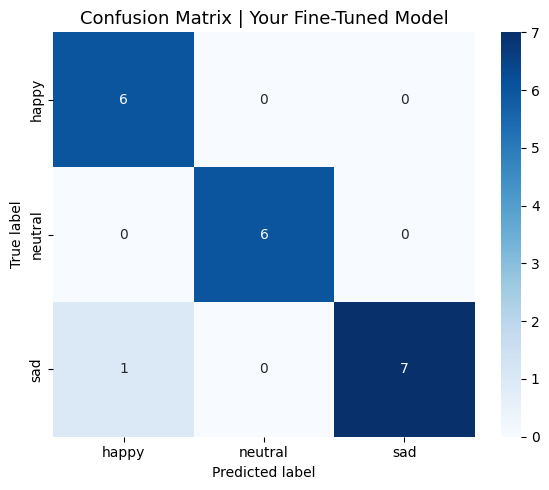

Read the matrix: row = true label, column = predicted label.
Off-diagonal values = mistakes. Which classes does your model confuse most?


In [19]:
# This will generate a matrix that shows which classes the model confuses with each other
# What a perfect model would look like? ALL values on the diagonal

cm = confusion_matrix(all_labels, all_preds)
class_names = ["happy", "neutral", "sad"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names,
    ax=ax
)
ax.set_title("Confusion Matrix | Your Fine-Tuned Model", fontsize=13)
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.savefig(figures_dir / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Read the matrix: row = true label, column = predicted label.")
print("Off-diagonal values = mistakes. Which classes does your model confuse most?")

## Reading the confusion matrix

Each row is the **true label**, each column is what the **model predicted**. The diagonal (top-left to bottom-right) are the correct predictions, the darker the better. Everything off the diagonal is a mistake.

**How to read each row:**
- **Happy row:** of all the sentences that were actually happy, how many did the model correctly call happy, and how many did it get wrong
- **Neutral row:** the most interesting one to watch. Neutral sentences are the hardest because they don't have strong emotional words, so the model tends to pull them toward happy or sad
- **Sad row:** of all the actually sad sentences, how many did it catch correctly

**What to look for in your matrix:**
- A dark diagonal = the model is doing its job
- Off-diagonal values in the neutral column = the model is being too conservative, labeling things as neutral when they're not
- Off-diagonal values in the happy or sad columns = the model is being too aggressive, seeing emotion where there isn't any

**The ideal matrix** would have all the numbers sitting on the diagonal and zeros everywhere else. You'll never quite get there with 200 examples, but the closer the better. If one row looks consistently wrong, that class needs more training data.

In [20]:
import time

# Run Groq zero-shot on the same test examples for a fair comparison
test_examples = []
with open(data_dir / "sentiment_test.jsonl") as f:
    for line in f:
        test_examples.append(json.loads(line.strip()))

print(f"Running Groq zero-shot on {len(test_examples)} test examples...")
print("(This makes one API call per example — takes ~30 seconds)\n")

groq_preds = []
true_labels_str = [ex["label"] for ex in test_examples]

for i, ex in enumerate(test_examples):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "You are a sentiment classifier. Respond with exactly one word: happy, neutral, or sad."},
            {"role": "user",   "content": f"Classify the sentiment: '{ex['text']}'"},
        ],
        temperature=0,
        max_tokens=5,
    )
    pred = response.choices[0].message.content.strip().lower()
    if pred not in VALID_LABELS:
        pred = "neutral"  # fallback fix for malformed responses
    groq_preds.append(pred)
    time.sleep(0.5)  # subtle rate limiting

groq_labels = [LABEL2ID[p] for p in groq_preds]
true_labels_int = [LABEL2ID[l] for l in true_labels_str]

groq_acc = accuracy_score(true_labels_int, groq_labels)
groq_f1  = f1_score(true_labels_int, groq_labels, average="macro")

print("\n" + "=" * 50)
print("  FINAL COMPARISON")
print("=" * 50)
print(f"  {'Model':<30} {'Accuracy':>10} {'F1':>8}")
print(f"  {'-'*30} {'-'*10} {'-'*8}")
print(f"  {'Your fine-tuned DistilBERT':<30} {test_acc*100:>9.1f}% {test_f1:>8.3f}")
print(f"  {'Groq zero-shot (Llama 3.1)':<30} {groq_acc*100:>9.1f}% {groq_f1:>8.3f}")
print(f"  {'Random baseline':<30} {'33.0':>9}% {'0.333':>8}")
print("=" * 50)

Running Groq zero-shot on 20 test examples...
(This makes one API call per example — takes ~30 seconds)


  FINAL COMPARISON
  Model                            Accuracy       F1
  ------------------------------ ---------- --------
  Your fine-tuned DistilBERT          95.0%    0.952
  Groq zero-shot (Llama 3.1)          85.0%    0.856
  Random baseline                     33.0%    0.333


## How to read the final comparison

So how does your fine-tuned model perform against zero-shot?

**The three models:**
- **Your fine-tuned DistilBERT:** a small model you trained yourself on a few hundred generated examples
- **Groq zero-shot (Llama 3.1):** a much larger model with no task-specific training, just a prompt
- **Random baseline:** what you'd get by guessing randomly across 3 classes, always around 33%

**What the results are really saying:**

Zero-shot outperforming your fine-tuned model here is completely expected and not a failure, it's actually the most important lesson of this module. The large model has been trained on orders of magnitude more data. The fact that your model gets anywhere close to it on only a couple hundred examples is the amazing part of this test.

The real advantage of your model isn't accuracy on this small test, it's everything else:
- **Speed:** DistilBERT runs locally in milliseconds per example vs hundreds of milliseconds for an API call
- **Cost:** zero per inference once trained, vs paying per token at scale
- **Control:** you own the model, it runs offline, no API dependency
- **Specialization:** with more training data your model would likely match or beat zero-shot on this specific task

The takeaway here is not "zero-shot is better." It's "now I understand the real tradeoff between models."

---

# Let's Visualize What the Model Actually Learned

## t-SNE: seeing inside the model

Your model internally represents every sentence as a vector of 768 numbers, this is usually called the `[CLS]` token embedding. We can't visualize 768 dimensions directly, but we can use **t-SNE** (t-distributed Stochastic Neighbor Embedding) to compress those 768 dimensions down to 2 while preserving the relative distances between points.

If your model has truly learned to distinguish sentiments, sentences with the same label should cluster together in that 2D space. If the clusters are clearly separated, the model has learned meaningful representations. If they're all mixed together, it hasn't.

In [21]:
import numpy as np
from sklearn.manifold import TSNE

def get_cls_embeddings(model, tokenizer, texts: list, device) -> np.ndarray:
    """
    Extract the CLS token embedding for each text.
    
    The CLS token is a special token prepended to every input.
    After processing, its embedding summarizes the entire sentence —
    that's why it's used for classification tasks.
    """
    model.eval()
    all_embeddings = []
    
    batch_size = 32
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        encodings = tokenizer(
            batch_texts,
            max_length=128,
            padding=True,
            truncation=True,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            # Access the base transformer (without the classification head)
            # to get raw embeddings
            outputs = best_model.distilbert(**encodings)
            # last_hidden_state[:, 0, :] = the CLS token for each example
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_emb)
    
    return np.vstack(all_embeddings)


# Use the full dataset for a more informative visualization
all_texts  = [ex["text"]  for ex in dataset]
all_labels = [ex["label"] for ex in dataset]

print("Extracting embeddings...")
embeddings = get_cls_embeddings(best_model, tokenizer, all_texts, device)
print(f"Embeddings shape: {embeddings.shape}  ({len(all_texts)} sentences × 768 dims)")

print("\nRunning t-SNE (this takes ~20 seconds)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
reduced = tsne.fit_transform(embeddings)
print(f"Reduced shape: {reduced.shape}  ({len(all_texts)} sentences × 2 dims)")

Extracting embeddings...
Embeddings shape: (200, 768)  (200 sentences × 768 dims)

Running t-SNE (this takes ~20 seconds)...
Reduced shape: (200, 2)  (200 sentences × 2 dims)


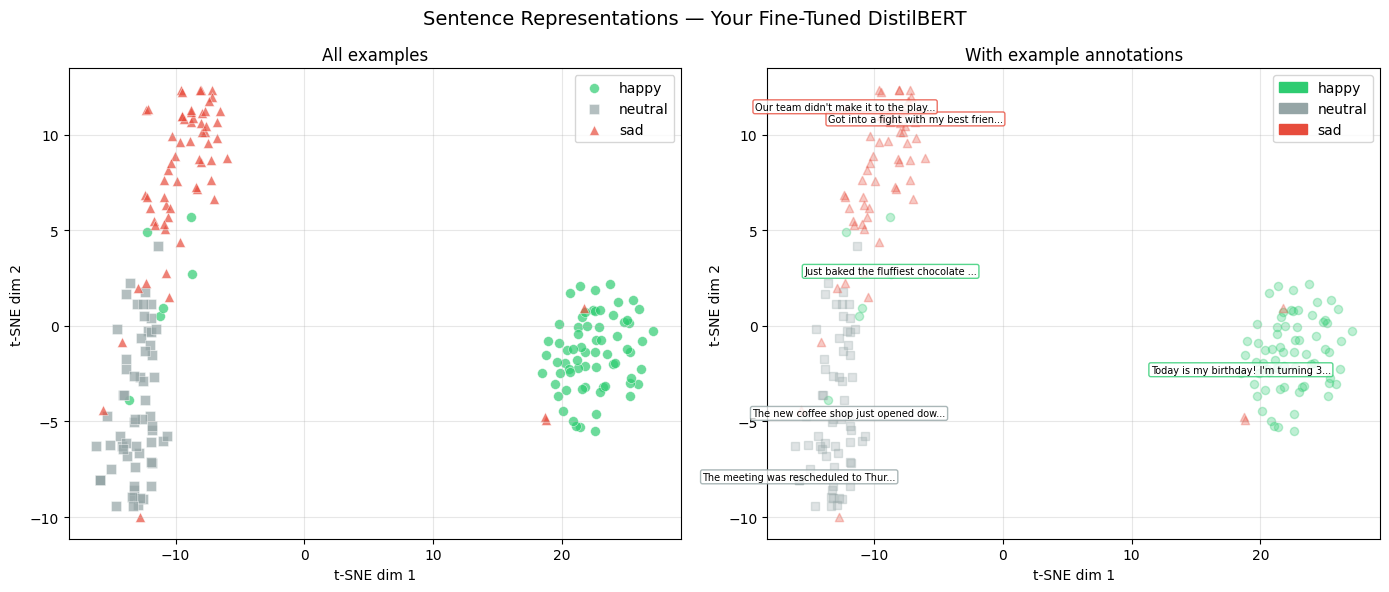


What you're looking at:
  Each dot = one sentence, compressed to 2D
  Nearby dots = sentences the model thinks are similar
  Distinct clusters = the model has learned to separate sentiments
  Overlap between clusters = cases the model finds ambiguous


In [22]:
colors  = {"happy": "#2ecc71", "neutral": "#95a5a6", "sad": "#e74c3c"}
markers = {"happy": "o",       "neutral": "s",         "sad": "^"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Sentence Representations — Your Fine-Tuned DistilBERT", fontsize=14)

# Left: all points colored by label
ax = axes[0]
ax.set_title("All examples")
for label in ["happy", "neutral", "sad"]:
    mask = np.array(all_labels) == label
    ax.scatter(
        reduced[mask, 0], reduced[mask, 1],
        c=colors[label], marker=markers[label],
        label=label, alpha=0.7, s=50, edgecolors="white", linewidths=0.4
    )
ax.legend()
ax.set_xlabel("t-SNE dim 1"), ax.set_ylabel("t-SNE dim 2")
ax.grid(alpha=0.3)

# Right: same plot with a few example sentences annotated
ax2 = axes[1]
ax2.set_title("With example annotations")
for label in ["happy", "neutral", "sad"]:
    mask = np.array(all_labels) == label
    ax2.scatter(
        reduced[mask, 0], reduced[mask, 1],
        c=colors[label], marker=markers[label],
        alpha=0.3, s=35
    )

# Annotate 2 examples per class
for label in ["happy", "neutral", "sad"]:
    indices = [i for i, l in enumerate(all_labels) if l == label][:2]
    for idx in indices:
        text = all_texts[idx][:35] + "..." if len(all_texts[idx]) > 35 else all_texts[idx]
        ax2.annotate(
            text, (reduced[idx, 0], reduced[idx, 1]),
            fontsize=7, ha="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor=colors[label])
        )

legend_patches = [mpatches.Patch(color=colors[l], label=l) for l in ["happy", "neutral", "sad"]]
ax2.legend(handles=legend_patches)
ax2.set_xlabel("t-SNE dim 1"), ax2.set_ylabel("t-SNE dim 2")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / "tsne_representations.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nWhat you're looking at:")
print("  Each dot = one sentence, compressed to 2D")
print("  Nearby dots = sentences the model thinks are similar")
print("  Distinct clusters = the model has learned to separate sentiments")
print("  Overlap between clusters = cases the model finds ambiguous")

## Reading the t-SNE visualization

Each dot is one sentence from your dataset, compressed from 768 dimensions down to 2 so we can actually see it. The position of each dot is determined by how your model represents that sentence internally, sentences the model thinks are similar end up close together.

**What to look for here:**

- **Distinct clusters by color:** if the green, grey and red dots are grouping separately, your model has learned meaningful representations for each sentiment. It's not just memorizing labels, it's actually understanding the difference between happy, neutral and sad language.

- **Overlap between clusters:** the areas where colors mix are the sentences your model finds genuinely ambiguous. This is normal and expected, some sentences really are hard to classify even for us.

- **Isolated dots far from their cluster:** these are your model's most confident mistakes. A red dot sitting deep inside the green cluster means the model is very sure that sentence is happy when it's actually sad. These are worth reading to understand where your model struggles.

**The right chart:** annotates a few real sentences so you can connect the position to the actual text. Notice how sentences with similar meaning or tone tend to sit close together even across different labels, that's your model's internal understanding of language showing through.

**The big picture here:** if you see three separated clouds of color, your model has done its job. The geometry of this plot is a preview of what your model actually learned, not just the final numbers, but the structure it built to get there.

---

# Key Takeaways of this module

## What we just did, don't worry I know it might be too much at first...

1. **We used zero-shot prompting** to classify sentiment with no training data, just a natural language instruction
2. **We used an LLM to generate training data** this is model distillation, and it's how many real ML teams build datasets today
3. **We fine-tuned DistilBERT** a 66M parameter model, on that generated data
4. **We compared the results** your model vs the general zero-shot approach

## The most important things to take back home

Large models know a lot because they've read a lot. That knowledge is exactly what makes zero-shot work, you don't need to teach them anything, you just describe the task. But broad knowledge has a cost: it's more general, not precise.

Fine-tuning allows you to do that. You take a small model and teach it one thing really really well. It stops being a generalist or basic model and becomes a specialized one. And specialists, on their own sauce, beat even much larger generalists.

This is a glimpse of how real ML systems work in production. A large model generates the data or labels the examples, and a small fast model does the actual work at scale. You've just built that pipeline from scratch.
## Ready to keep testing?

- Increase the dataset to 500 examples, the model accuracy improve or not?
- Add a 4th class or 5th class ("angry", "sarcasm") and regenerate the dataset, how does the model handle it at the end?
- Look at your model's worst predictions, any pattern within those sentences? How you could fix it before the generation and classification?

---

## Next module

**[Module 1 — Few-Shot Prompting →](../../01_few_shot/notebooks/01_few_shot_prompting.ipynb)**

You'll learn how providing 2–5 examples in the prompt, no fine-tuning, can change a model behavior on specialized tasks.